In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
pd.set_option('display.max_columns', None)

data = pd.read_csv('animal-shelter-intakes-and-outcomes.csv')

In [4]:
animal_data = data[['Animal Type', "DOB", 'Primary Color', 'Secondary Color', 'Sex', 'Intake Date', 'Intake Condition', 'Intake Type', 'Outcome Date',
                    'Outcome Type']].copy()

animal_data = animal_data.rename(
    columns={
            "Animal Type": "Animal_Type",
            "DOB" : "DOB",
            "Primary Color" : "Primary_Color",
            "Secondary Color" : "Secondary_Color",
            "Sex" : "Sex",
            "Intake Date" : "Intake_Date",
            "Intake Condition": "Intake_Condition",
            "Intake Type" : "Intake_Type",
            "Outcome Date" : "Outcome_Date",
            "Outcome Type" : "Outcome_Type"
    }
)

In [5]:
animal_data.sample(100)

,Animal_Type,DOB,Primary_Color,Secondary_Color,Sex,Intake_Date,Intake_Condition,Intake_Type,Outcome_Date,Outcome_Type
24273,DOG,2016-01-26,WHITE,BROWN,Male,2020-01-26,INJURED MODERATE,STRAY,2020-02-08,RESCUE
27647,CAT,2014-03-08,GRAY,NaN,Female,2017-03-08,NORMAL,STRAY,2017-03-16,TRANSFER
15032,DOG,2011-08-30,BR BRINDLE,WHITE,Female,2020-08-30,NORMAL,STRAY,2020-08-30,RETURN TO OWNER
14602,DOG,2018-01-22,BLACK,BROWN,Female,2019-01-22,NORMAL,CONFISCATE,2019-02-02,TRANSFER
24323,CAT,2024-03-06,BRN TABBY,NaN,Neutered,2024-06-06,UNDER AGE/WEIGHT,STRAY,2024-06-21,ADOPTION
...,...,...,...,...,...,...,...,...,...,...
6444,CAT,2023-03-06,GRAY,WHITE,Female,2023-04-06,UNDER AGE/WEIGHT,STRAY,2023-04-07,RESCUE
15891,CAT,2014-11-27,BLACK,WHITE,Female,2019-11-27,NORMAL,STRAY,2019-12-01,RETURN TO OWNER
8511,CAT,2018-08-14,CALICO DIL,NaN,Spayed,2019-08-14,NORMAL,OWNER SURRENDER,2019-08-27,DIED
27988,CAT,2016-02-28,BLACK,NaN,Neutered,2018-02-28,FRACTIOUS,STRAY,2018-03-16,"SHELTER, NEUTER, RETURN"


In [6]:
animal_data.describe() 

,Animal_Type,DOB,Primary_Color,Secondary_Color,Sex,Intake_Date,Intake_Condition,Intake_Type,Outcome_Date,Outcome_Type
count,30475,26717,30475,14587,30475,30475,30475,30475,30284,30276
unique,10,5734,81,46,5,2889,17,12,2876,18
top,CAT,2018-04-10,BLACK,WHITE,Male,2023-05-03,NORMAL,STRAY,2021-10-02,RESCUE
freq,14359,35,7757,8520,6980,75,14145,21498,44,7020


In [7]:
animal_data['Secondary_Color'] = animal_data['Secondary_Color'].fillna("None") 
animal_data['Outcome_Type'] = animal_data['Outcome_Type'].fillna("Unknown")

animal_data["DOB"] = pd.to_datetime(animal_data["DOB"])
animal_data["Intake_Date"] = pd.to_datetime(animal_data["Intake_Date"])
animal_data["Outcome_Date"] = pd.to_datetime(animal_data["Outcome_Date"])

animal_data = animal_data.astype(
    {"Animal_Type" : "object",
     "DOB" : "datetime64[ns]",
     "Primary_Color" : "category",
     "Secondary_Color" : "category",
     "Sex" : "category",
     "Intake_Date" : "datetime64[ns]",
     "Intake_Condition" : "category",
     "Intake_Type" : "category",
     "Outcome_Date" : "datetime64[ns]",
     "Outcome_Type" : "category" 
     }
)

In [8]:
animal_data['Intake_Age'] = animal_data['Intake_Date'] - animal_data['DOB']
animal_data['Outcome_Age'] = animal_data['Outcome_Date'] - animal_data['DOB']
animal_data['Days_in_Shelter'] = animal_data['Outcome_Date'] - animal_data['Intake_Date']

animal_data = animal_data[
    (animal_data['Intake_Age'] > pd.Timedelta('0')) &
    (animal_data['Intake_Age'] < pd.Timedelta('18000 days 00:00:00')) &
    (animal_data['Outcome_Age'] < pd.Timedelta('18000 days 00:00:00'))
]
animal_data = animal_data.reset_index(drop=True)

animal_data['Breed'] = 'Unknown'
animal_data['Shelter_Name'] = 'Long Beach California Animal Shelter'

animal_data['Intake_Age'] = animal_data['Intake_Age'].astype(str)
animal_data['Intake_Age'] = animal_data['Intake_Age'].str.replace(' days', '', regex=False)

In [9]:
print(f'Columns: {animal_data.columns}')
print(f'Types: {animal_data.dtypes}')
print(f'Shape: {animal_data.shape}')

Columns: Index(['Animal_Type', 'DOB', 'Primary_Color', 'Secondary_Color', 'Sex',
       'Intake_Date', 'Intake_Condition', 'Intake_Type', 'Outcome_Date',
       'Outcome_Type', 'Intake_Age', 'Outcome_Age', 'Days_in_Shelter', 'Breed',
       'Shelter_Name'],
      dtype='object')
Types: Animal_Type                  object
DOB                  datetime64[ns]
Primary_Color              category
Secondary_Color            category
Sex                        category
Intake_Date          datetime64[ns]
Intake_Condition           category
Intake_Type                category
Outcome_Date         datetime64[ns]
Outcome_Type               category
Intake_Age                   object
Outcome_Age         timedelta64[ns]
Days_in_Shelter     timedelta64[ns]
Breed                        object
Shelter_Name                 object
dtype: object
Shape: (26047, 15)


In [10]:
missing_values = animal_data.isna().sum()
print(f"Missing values:\n {missing_values}")
animal_data = animal_data.dropna()
print("Missing Values Dropped ")

duplicated_values = animal_data.duplicated().sum()
print(f"Duplicated Values: {duplicated_values}")
animal_data = animal_data.drop_duplicates()
print("Duplicated Values Dropped")

print(f'Shape: {animal_data.shape}')
animal_data = animal_data.reset_index(drop=True)

Missing values:
 Animal_Type         0
DOB                 0
Primary_Color       0
Secondary_Color     0
Sex                 0
Intake_Date         0
Intake_Condition    0
Intake_Type         0
Outcome_Date        0
Outcome_Type        0
Intake_Age          0
Outcome_Age         0
Days_in_Shelter     0
Breed               0
Shelter_Name        0
dtype: int64
Missing Values Dropped 
Duplicated Values: 1329
Duplicated Values Dropped
Shape: (24718, 15)


In [27]:
animal_data.to_csv('Long_Beach_Animal_Data.csv', index=False)
print(animal_data.columns)
print(animal_data['Shelter_Name'].value_counts())

Index(['Animal_Type', 'DOB', 'Primary_Color', 'Secondary_Color', 'Sex',
       'Intake_Date', 'Intake_Condition', 'Intake_Type', 'Outcome_Date',
       'Outcome_Type', 'Intake_Age', 'Outcome_Age', 'Days_in_Shelter', 'Breed',
       'Shelter_Name'],
      dtype='object')
Shelter_Name
Long Beach California Animal Shelter    24718
Name: count, dtype: int64


Because the Outcome Dates and Types are close together it is most likely that the data has not yet been entered or the shelter animal is still in care, so the data is just unavailable at this time.

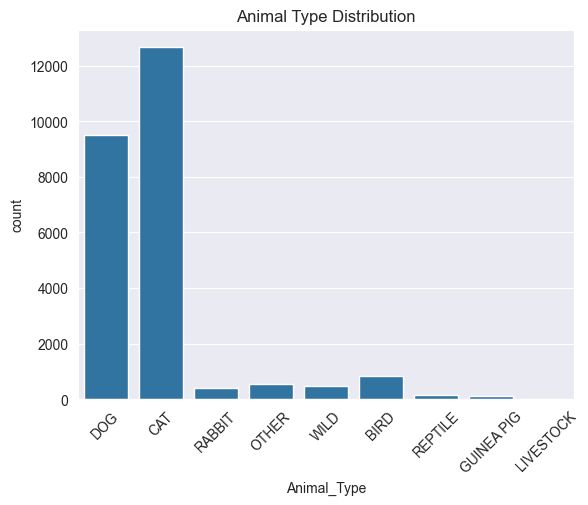

In [12]:
ax = sns.countplot(data=animal_data, x="Animal_Type")
ax.tick_params(axis='x', rotation=45)
ax.set_title("Animal Type Distribution")
plt.show()

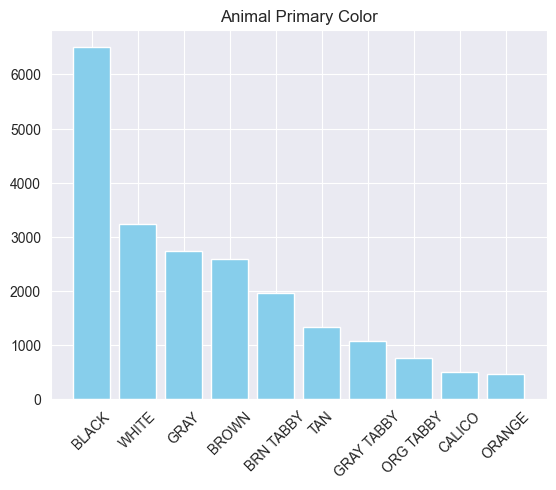

In [13]:
animal_color_count = animal_data['Primary_Color'].value_counts()
plt.bar(x=animal_color_count.index[:10], height=animal_color_count.values[:10], color='skyblue')
plt.xticks(rotation=45)
plt.title("Animal Primary Color")
plt.show()

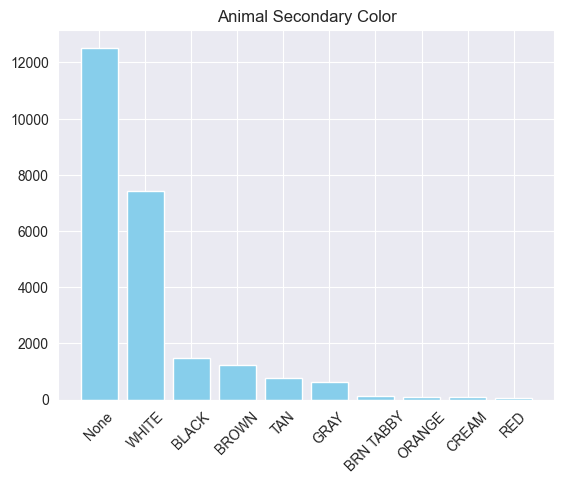

In [14]:
animal_color_count = animal_data['Secondary_Color'].value_counts()
plt.bar(x=animal_color_count.index[:10], height=animal_color_count.values[:10], color='skyblue')
plt.xticks(rotation=45)
plt.title("Animal Secondary Color")
plt.show()

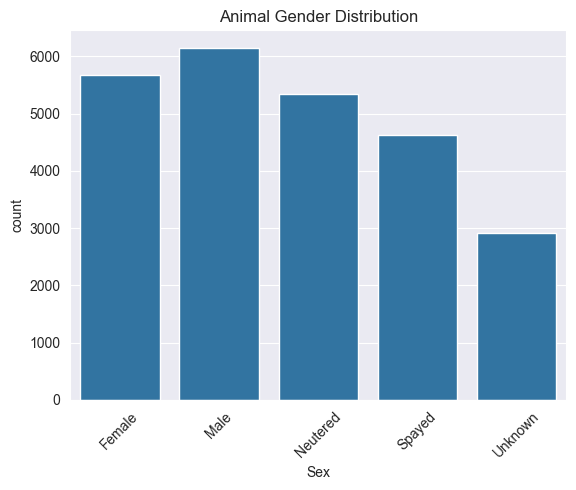

In [15]:
ax = sns.countplot(data=animal_data, x='Sex')
ax.tick_params(axis='x', rotation=45)
ax.set_title("Animal Gender Distribution")
plt.show()

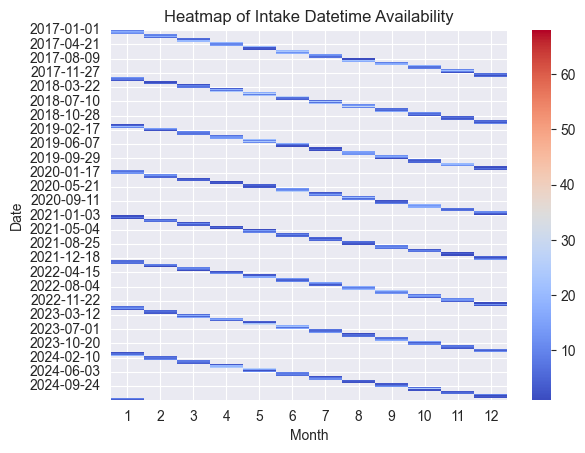

0        True
1        True
2        True
3        True
4        True
         ... 
24713    True
24714    True
24715    True
24716    True
24717    True
Name: Intake_Datetime_Available, Length: 24718, dtype: bool

In [16]:
animal_data['Intake_Datetime_Available'] = animal_data['Intake_Date'].notnull()

heatmap_data = animal_data.pivot_table(
    index=animal_data['Intake_Date'].dt.date,
    columns=animal_data['Intake_Date'].dt.month,
    values='Intake_Datetime_Available',
    aggfunc='count'
)

sns.heatmap(heatmap_data, cmap="coolwarm", cbar=True)
plt.title("Heatmap of Intake Datetime Availability")
plt.xlabel("Month")
plt.ylabel("Date")
plt.show()

animal_data.pop("Intake_Datetime_Available")

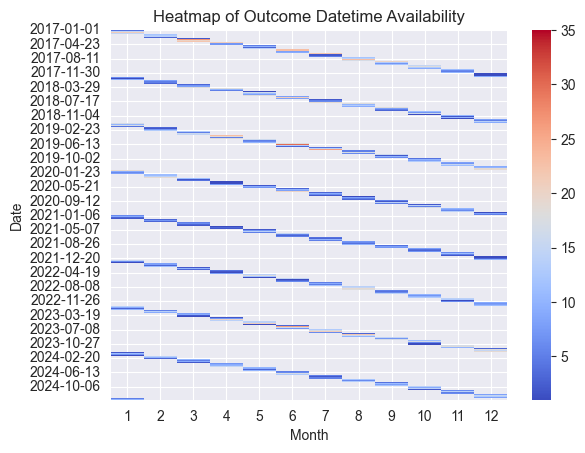

0        True
1        True
2        True
3        True
4        True
         ... 
24713    True
24714    True
24715    True
24716    True
24717    True
Name: Outcome_Datetime_Available, Length: 24718, dtype: bool

In [17]:
animal_data['Outcome_Datetime_Available'] = animal_data['Outcome_Date'].notnull()

heatmap_data = animal_data.pivot_table(
    index=animal_data['Outcome_Date'].dt.date,
    columns=animal_data['Outcome_Date'].dt.month,
    values='Outcome_Datetime_Available',
    aggfunc='count'
)

sns.heatmap(heatmap_data, cmap="coolwarm", cbar=True)
plt.title("Heatmap of Outcome Datetime Availability")
plt.xlabel("Month")
plt.ylabel("Date")
plt.show()

animal_data.pop("Outcome_Datetime_Available")

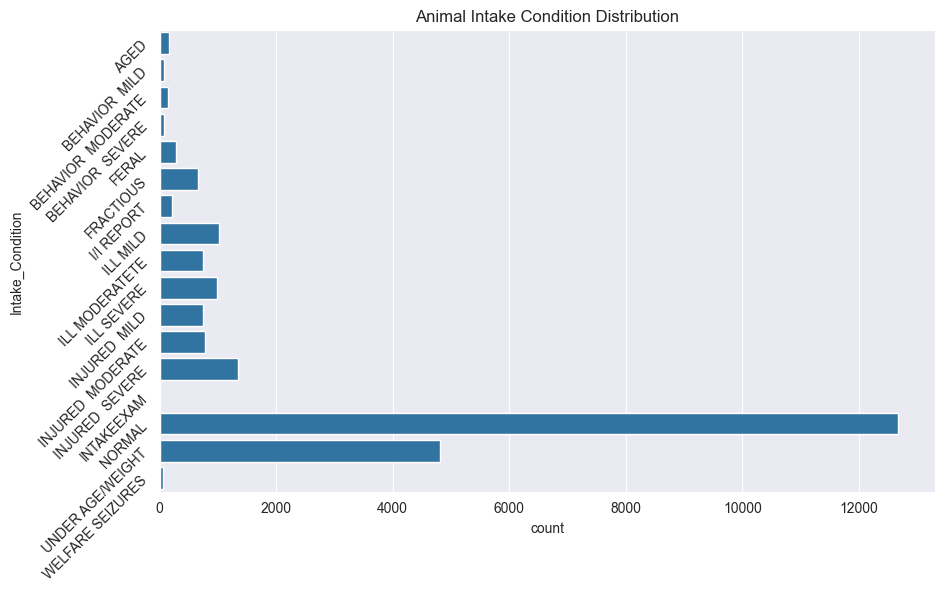

In [18]:
plt.figure(figsize=(10, 6))
ax = sns.countplot(animal_data, y='Intake_Condition')
ax.tick_params(axis='y', rotation=45)
ax.set_title("Animal Intake Condition Distribution")
plt.show()

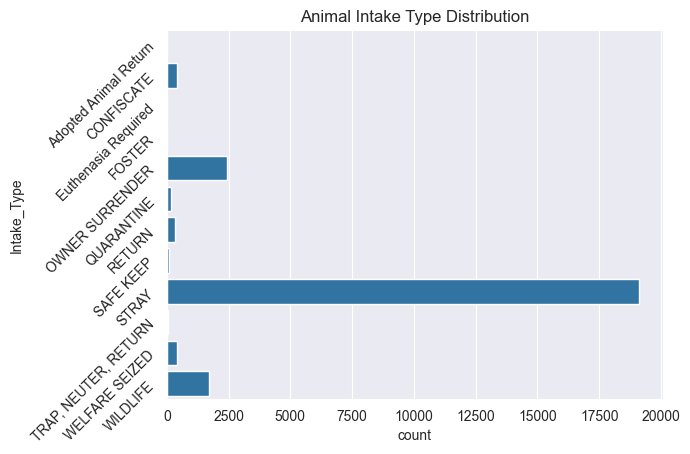

In [19]:
ax = sns.countplot(data=animal_data, y='Intake_Type')
ax.set_title("Animal Intake Type Distribution")
ax.tick_params(axis='y', rotation=45)
plt.show()

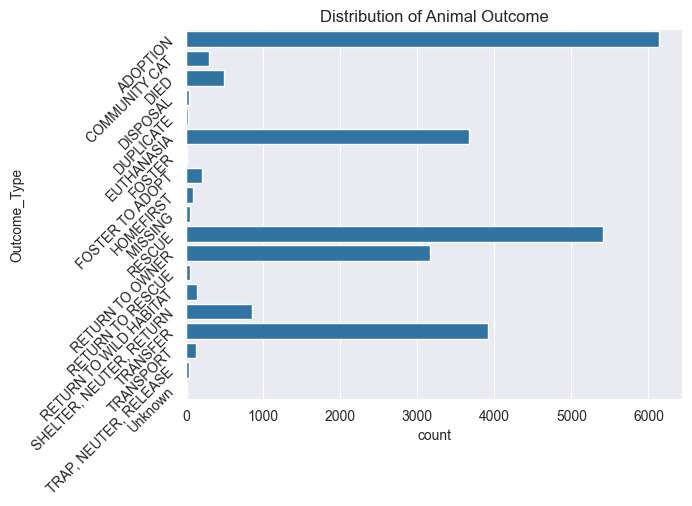

In [20]:
ax = sns.countplot(data=animal_data, y='Outcome_Type')
ax.set_title("Distribution of Animal Outcome")
ax.tick_params(axis='y', rotation=45)
plt.show()

In [21]:
animal_data['Days_in_Shelter'].value_counts()

Days_in_Shelter
0 days      5167
1 days      2431
6 days      1654
2 days      1052
3 days      1045
            ... 
306 days       1
327 days       1
504 days       1
219 days       1
334 days       1
Name: count, Length: 370, dtype: int64

In [22]:
animal_data['Days_in_Shelter'].head(100)

0     6 days
1    26 days
2     7 days
3    28 days
4     0 days
       ...  
95    0 days
96    6 days
97    0 days
98    0 days
99    0 days
Name: Days_in_Shelter, Length: 100, dtype: timedelta64[ns]

In [28]:
animal_data['Days_in_Shelter'].value_counts()

Days_in_Shelter
0 days      5167
1 days      2431
6 days      1654
2 days      1052
3 days      1045
            ... 
306 days       1
327 days       1
504 days       1
219 days       1
334 days       1
Name: count, Length: 370, dtype: int64

In [26]:
animal_data.columns

Index(['Animal_Type', 'DOB', 'Primary_Color', 'Secondary_Color', 'Sex',
       'Intake_Date', 'Intake_Condition', 'Intake_Type', 'Outcome_Date',
       'Outcome_Type', 'Intake_Age', 'Outcome_Age', 'Days_in_Shelter', 'Breed',
       'Shelter_Name'],
      dtype='object')